In [121]:
#importing libraries
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;
from sklearn.cluster import KMeans;

In [122]:
#reading data file
df=pd.read_csv('Mall_Customers.csv')

In [123]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [124]:
#df information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [125]:
#df.stats
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [126]:
df.shape

(200, 5)

In [127]:
df.isnull().sum() #no null values

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [128]:
df.duplicated().sum() #no duplicates

0

In [129]:
#label encoding gender categorical variable
from sklearn.preprocessing import LabelEncoder

In [130]:
LE=LabelEncoder()
df['Gender_new']=LE.fit_transform(df['Gender'])

In [131]:
df.drop('Gender',axis=1,inplace=True)
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_new
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0


In [132]:
#select features and doing normalization or standardization
df_new=df.drop('CustomerID',axis=1)

In [133]:
df_new2=df.drop(['CustomerID','Gender_new'],axis=1)

In [134]:
df_new.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_new
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


In [135]:
df_new2.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [136]:
from sklearn.preprocessing import StandardScaler
X=StandardScaler()
X_scaled=X.fit_transform(df_new)
X1_scaled=X.fit_transform(df_new2)
print(X_scaled,'\t',X1_scaled )

[[-1.42456879 -1.73899919 -0.43480148  1.12815215]
 [-1.28103541 -1.73899919  1.19570407  1.12815215]
 [-1.3528021  -1.70082976 -1.71591298 -0.88640526]
 [-1.13750203 -1.70082976  1.04041783 -0.88640526]
 [-0.56336851 -1.66266033 -0.39597992 -0.88640526]
 [-1.20926872 -1.66266033  1.00159627 -0.88640526]
 [-0.27630176 -1.62449091 -1.71591298 -0.88640526]
 [-1.13750203 -1.62449091  1.70038436 -0.88640526]
 [ 1.80493225 -1.58632148 -1.83237767  1.12815215]
 [-0.6351352  -1.58632148  0.84631002 -0.88640526]
 [ 2.02023231 -1.58632148 -1.4053405   1.12815215]
 [-0.27630176 -1.58632148  1.89449216 -0.88640526]
 [ 1.37433211 -1.54815205 -1.36651894 -0.88640526]
 [-1.06573534 -1.54815205  1.04041783 -0.88640526]
 [-0.13276838 -1.54815205 -1.44416206  1.12815215]
 [-1.20926872 -1.54815205  1.11806095  1.12815215]
 [-0.27630176 -1.50998262 -0.59008772 -0.88640526]
 [-1.3528021  -1.50998262  0.61338066  1.12815215]
 [ 0.94373197 -1.43364376 -0.82301709  1.12815215]
 [-0.27630176 -1.43364376  1.85

In [137]:
kmeans=KMeans(n_clusters=2)
kmeans.fit(X_scaled)

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=2, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=None, tol=0.0001, verbose=0)

In [138]:
kmeans.labels_

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [139]:
kmeans.inertia_ #inertia is very high for 2 clusters

588.8026767824936

In [140]:
from sklearn.metrics import silhouette_samples, silhouette_score

In [141]:
#Lets find optimal number of clusters using elbow method
clust=[]
sc=[]
for i in range(2,21):
    km=KMeans(n_clusters=i,n_init=50,random_state=42)
    km.fit(X_scaled)
    l=km.labels_
    y=km.fit_predict(X_scaled)
    clust.append(km.inertia_)
    sc.append(silhouette_score(X_scaled,y))
    print(f"\nCluster sizes for k={i}:")
    print(pd.Series(y).value_counts().sort_index())


Cluster sizes for k=2:
0     97
1    103
dtype: int64

Cluster sizes for k=3:
0    85
1    66
2    49
dtype: int64

Cluster sizes for k=4:
0    56
1    40
2    56
3    48
dtype: int64

Cluster sizes for k=5:
0    31
1    31
2    40
3    55
4    43
dtype: int64

Cluster sizes for k=6:
0    44
1    39
2    23
3    29
4    37
5    28
dtype: int64

Cluster sizes for k=7:
0    43
1    25
2    22
3    29
4    37
5    26
6    18
dtype: int64

Cluster sizes for k=8:
0    20
1    18
2    36
3    34
4    19
5    24
6    27
7    22
dtype: int64

Cluster sizes for k=9:
0    15
1    24
2    33
3    27
4    13
5    29
6    19
7    18
8    22
dtype: int64

Cluster sizes for k=10:
0    14
1    18
2    14
3    25
4    19
5    24
6    26
7    21
8    26
9    13
dtype: int64

Cluster sizes for k=11:
0     24
1     21
2     20
3     21
4     26
5     23
6     14
7     18
8     13
9      6
10    14
dtype: int64

Cluster sizes for k=12:
0     24
1     13
2     21
3     26
4     25
5     20
6     14
7     1

In [142]:
#Lets find optimal number of clusters using elbow method
clust1=[]
sc1=[]
for i in range(2,21):
    km1=KMeans(n_clusters=i,n_init=50,random_state=42)
    km1.fit(X1_scaled)
    l1=km1.labels_
    y1=km1.fit_predict(X1_scaled)
    clust1.append(km1.inertia_)
    sc1.append(silhouette_score(X1_scaled,y1))
    print(f"\nCluster sizes for k={i}:")
    print(pd.Series(y1).value_counts().sort_index())


Cluster sizes for k=2:
0     97
1    103
dtype: int64

Cluster sizes for k=3:
0    91
1    68
2    41
dtype: int64

Cluster sizes for k=4:
0    38
1    57
2    40
3    65
dtype: int64

Cluster sizes for k=5:
0    54
1    47
2    40
3    20
4    39
dtype: int64

Cluster sizes for k=6:
0    21
1    39
2    33
3    24
4    45
5    38
dtype: int64

Cluster sizes for k=7:
0    34
1    39
2    33
3    30
4    24
5    20
6    20
dtype: int64

Cluster sizes for k=8:
0    32
1    23
2    39
3    19
4    20
5    32
6    15
7    20
dtype: int64

Cluster sizes for k=9:
0    32
1    22
2    39
3    19
4    10
5    32
6    15
7    20
8    11
dtype: int64

Cluster sizes for k=10:
0    32
1    15
2    20
3    11
4    11
5    19
6    22
7    32
8    28
9    10
dtype: int64

Cluster sizes for k=11:
0     30
1     32
2      8
3     28
4     20
5     22
6     11
7     11
8     17
9     10
10    11
dtype: int64

Cluster sizes for k=12:
0     11
1     20
2     17
3     12
4     22
5     20
6     10
7     2

In [143]:
print(clust , '\n************', clust1)

[588.8026767824936, 476.78755441351586, 386.8284255837667, 325.10998348953444, 275.030671001447, 235.62979906822056, 199.7166255966767, 174.11984372928396, 152.0298342977569, 137.18781906663153, 125.31014993942077, 114.36975653488784, 106.36046082204044, 100.21210766177428, 92.07576947549762, 87.46398642601548, 82.54076880128895, 77.82353854819365, 73.60146310628754] 
************ [389.3861889564372, 295.2122461555488, 205.22514747675916, 168.24758017556837, 133.86833362685584, 117.04562632908552, 103.87329152383714, 92.01487454135659, 81.82407435412267, 71.96171250436751, 66.95362379281843, 63.4947716493051, 59.13901225456742, 56.35772167968467, 53.30620720832939, 50.913086829125334, 48.88979190628519, 46.643195769855794, 44.66831207713364]


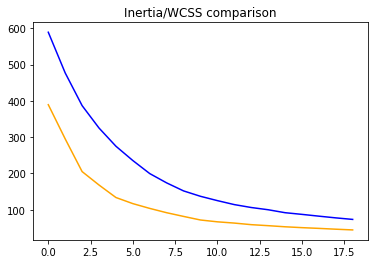

In [144]:
plt.plot(range(0,19),clust,color='blue')
plt.plot(range(0,19),clust1,color='Orange')
plt.title('Inertia/WCSS comparison')
plt.show()

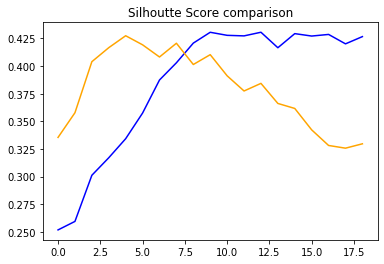

In [145]:
plt.plot(range(0,19), sc,color='blue')
plt.plot(range(0,19), sc1,color='Orange')
plt.title('Silhoutte Score comparison') 
plt.show()

In [146]:
df_new['Cluster']=y
print(df_new)

     Age  Annual Income (k$)  Spending Score (1-100)  Gender_new  Cluster
0     19                  15                      39           1        6
1     21                  15                      81           1        6
2     20                  16                       6           0        2
3     23                  16                      77           0       13
4     31                  17                      40           0        2
..   ...                 ...                     ...         ...      ...
195   35                 120                      79           0        1
196   45                 126                      28           0       19
197   32                 126                      74           1       17
198   32                 137                      18           1       16
199   30                 137                      83           1       17

[200 rows x 5 columns]


## Blue line - If we take gender as well in the feature set, the max sc score is 0.425 with 8-10 clusters. 
## Orange line - After removing gender from the features,we got better inertia with fewer clusters and almost same sc score.

In [160]:
# Optimal no.of clusters =5
kmeans=KMeans(n_clusters=5)
kmeans.fit(X1_scaled)
y1_pred=kmeans.fit_predict(X1_scaled)
print(kmeans.labels_)
print(kmeans.inertia_)
print(silhouette_score(X1_scaled,y1_pred))

[2 2 0 2 2 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 3 2 0 2 0 2 3 2 2 2 3 2 2 3 3 3 3 3 2 3 3 2 3 3 3 2 3 3 2 2 3 3 3 3
 3 2 3 3 2 3 3 2 3 3 2 3 3 2 2 3 3 2 3 3 2 2 3 2 3 2 2 3 3 2 3 2 3 3 3 3 3
 2 4 2 2 2 3 3 3 3 2 4 1 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1
 4 1 4 1 4 1 4 1 4 1 4 1 3 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1 4
 1 4 1 4 1 4 1 4 1 4 1 4 1 4 1]
168.24758017556837
0.41664341513732767


In [161]:
df_new2['Cluster']=y1_pred
df_new2

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,19,15,39,2
1,21,15,81,2
2,20,16,6,0
3,23,16,77,2
4,31,17,40,2
...,...,...,...,...
195,35,120,79,1
196,45,126,28,4
197,32,126,74,1
198,32,137,18,4


In [162]:
cluster_summary =df_new2.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,32.875000,86.100000,81.525000
2,25.185185,41.092593,62.240741
3,55.638298,54.382979,48.851064
4,39.871795,86.102564,19.358974


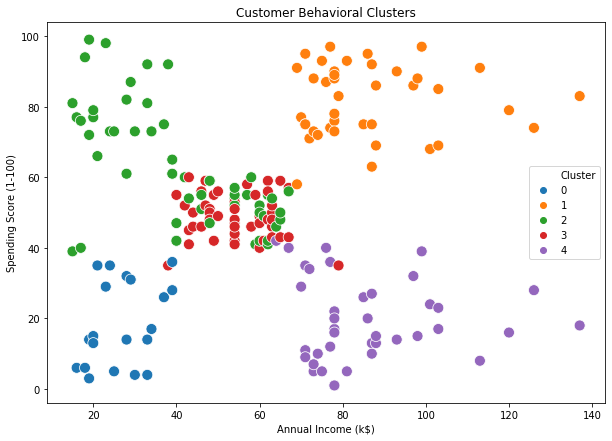

In [163]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=df_new2,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='tab10',
    s=120
)

plt.title('Customer Behavioral Clusters')
plt.show()

# Insights from this:
## Cluster 4 people are middle aged with very High income but very less spending. These are Budget Spenders
## Cluster 2 people are young with low income and high spending.
## People who are less than 40 have high spending habits compared to 40+ aged people